In [1]:
import glob
import os
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar 
from skrf import Network, Frequency
import math
import psutil
import matplotlib.cm as cm
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import csv
import pandas as pd
import sys
sys.path.insert(0, '../classes/')
import time_utils as tu

style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
    convert seconds to degrees of sky motion at a latitude default TONE latitude default for cra
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
    Reading all hdf5 files
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()
    
    #grab different sets of files.  
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            #print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                #print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                #print("Appended vis data and time stream from %s" % (x))
        
        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(power0):
    """
    # return magnitude and phase in degrees of correlations
    """
    return np.absolute(power0), np.rad2deg(np.angle(power0))

def plot_waterfall_corr_data(data, corr_indices):
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index 
        plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
    plt.tight_layout()
    
def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            #plt.plot(pow_mag[:, freq_index, corr_index]00000053.h5)
            plt.plot(pow_mag[:, :, corr_index])

    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()


In [2]:
drone_data_path = "../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-03-58PM-Flight-Airdata.csv"

In [3]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# from matplotlib.ticker import FuncFormatter, AutoLocator, AutoMinorLocator
# from IPython.display import HTML
# import numpy as np

# drone_data_path = "../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-03-58PM-Flight-Airdata.csv"

# # === Load and downsample data ===
# df = pd.read_csv(drone_data_path)
# step = 10  # keep every 10th point to reduce size
# lat = df["latitude"].values[::step]
# lon = df["longitude"].values[::step]
# alt = df["altitude(feet)"].values[::step]
# timestamps = pd.to_datetime(df["datetime(utc)"].values)[::step]

# # === Reference point for metric scale (origin corner) ===
# lat0, lon0 = lat[0], lon[0]

# # === Convert lat/lon to approximate meters ===
# def latlon_to_meters(lat_ref, lon_ref, lat_vals, lon_vals):
#     R = 6371000  # Earth radius in meters
#     lat_rad = np.radians(lat_ref)
#     dlat = np.radians(lat_vals - lat_ref)
#     dlon = np.radians(lon_vals - lon_ref)
#     x = dlon * R * np.cos(lat_rad)
#     y = dlat * R
#     return x, y

# # === Set up figure and axes ===
# fig, ax = plt.subplots(figsize=(8, 6))
# line, = ax.plot([], [], lw=2, color='blue')
# point, = ax.plot([], [], 'ro')
# alt_label = ax.text(0, 0, '', fontsize=12, ha='left', va='bottom')
# title = ax.set_title("")

# # Latitude/Longitude limits
# margin = 0.00005
# ax.set_xlim(min(lon) - margin, max(lon) + margin)
# ax.set_ylim(min(lat) - margin, max(lat) + margin)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

# # === Add secondary axes in meters (with minor ticks) ===
# ax_m = ax.secondary_xaxis('top')
# ax_m.set_xlabel("Distance (m) from origin (E-W)")
# ax_m.xaxis.set_major_formatter(FuncFormatter(
#     lambda x, _: f"{latlon_to_meters(lat0, lon0, lat0, x)[0]:.0f}"
# ))
# ax_m.xaxis.set_minor_locator(AutoMinorLocator())

# ay_m = ax.secondary_yaxis('right')
# ay_m.set_ylabel("Distance (m) from origin (N-S)")
# ay_m.yaxis.set_major_formatter(FuncFormatter(
#     lambda y, _: f"{latlon_to_meters(lat0, lon0, y, lon0)[1]:.0f}"
# ))
# ay_m.yaxis.set_minor_locator(AutoMinorLocator())

# # === Init function ===
# def init():
#     line.set_data([], [])
#     point.set_data([], [])
#     alt_label.set_text('')
#     title.set_text('')
#     return line, point, alt_label, title

# # === Update frame function ===
# def update(frame):
#     line.set_data(lon[:frame+1], lat[:frame+1])
#     point.set_data([lon[frame]], [lat[frame]])
#     alt_label.set_position((lon[frame], lat[frame]))
#     alt_label.set_text(f"{alt[frame]:.1f} ft")
#     title.set_text(f"Time: {timestamps[frame].strftime('%H:%M:%S')}")
#     return line, point, alt_label, title

# # === Create animation ===
# ani = animation.FuncAnimation(
#    fig, update, frames=len(lat), init_func=init, blit=True, interval=50
# )

# # === Display animation
# HTML(ani.to_jshtml())


In [4]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import *
from matplotlib import pyplot as plt
import datetime
import h5py
import os
import pygeodesy

def drone_angles_for_corr_range_simple(dish_location, drone_file, corr_data_directory,
                                       start_file=0, stop_file=-1,
                                       use_ctime=False, output='degrees'):
    """
    Compute drone angles relative to a single dish location for a specific correlator file time range.
    Interpolates the drone positions to the correlator timestamps.

    Time handling matches the concat script: all times converted to float seconds since epoch.
    """

    # -----------------------
    # Step 1: Load correlator timestamps
    # -----------------------
    all_files = sorted([f for f in os.listdir(corr_data_directory) if ".lock" not in f])
    filenames = all_files[start_file:stop_file]
    if len(filenames) == 0:
        raise ValueError("No correlator files found in the specified range.")

    t_list = []
    for fname in filenames:
        with h5py.File(os.path.join(corr_data_directory, fname), 'r') as fd:
            if use_ctime:
                t_file = fd['index_map']['time']['ctime'][:].astype(float)
            else:
                t_file = 1e-9 * fd['index_map']['time']['irigb_time'][:].astype(float)
            t_list.append(t_file)
    t_corr = np.concatenate(t_list)

    # Convert correlator times to seconds since epoch
    t_corr_sec = t_corr if use_ctime else t_corr  # already in seconds
    # fallback: ensure numeric type
    t_corr_sec = np.array(t_corr_sec, dtype=float)

    # -----------------------
    # Step 2: Load drone CSV timestamps
    # -----------------------
    df = pd.read_csv(drone_file, low_memory=False)

    if 'datetime(utc)' in df.columns and 'time(millisecond)' in df.columns:
        t0 = pd.to_datetime(df['datetime(utc)'], utc=True).iloc[0]
        drone_times = np.array([(t0 + datetime.timedelta(milliseconds=x)).timestamp()
                                for x in df['time(millisecond)']])
    elif 'GPS:dateTimeStamp' in df.columns:
        drone_times = pd.to_datetime(df['GPS:dateTimeStamp'], utc=True).map(lambda t: t.timestamp()).values
    else:
        raise KeyError("No recognizable time columns in drone file.")

    # -----------------------
    # Step 3: Mask drone data to correlator time range
    # -----------------------
    t_start_sec, t_stop_sec = t_corr_sec[0], t_corr_sec[-1]
    mask = (drone_times >= t_start_sec) & (drone_times <= t_stop_sec)
    if not mask.any():
        raise ValueError("No drone data falls within the correlator time range.")
    df_masked = df.loc[mask].copy()
    drone_times = drone_times[mask]

    # -----------------------
    # Step 4: Extract drone positions
    # -----------------------
    if 'RTKdata:Lat_P' in df_masked.columns:
        lat = df_masked['RTKdata:Lat_P'].values
        lon = df_masked['RTKdata:Lon_P'].values
        alt = df_masked['RTKdata:Hmsl_P'].values
    elif 'GPS(0):Lat' in df_masked.columns:
        lat = df_masked['GPS(0):Lat'].values
        lon = df_masked['GPS(0):Long'].values
        alt = df_masked['GPS(0):heightMSL'].values
    elif 'GPS:Lat' in df_masked.columns:
        lat = df_masked['GPS:Lat'].values
        lon = df_masked['GPS:Long'].values
        alt = df_masked['GPS:heightMSL'].values
    elif 'latitude' in df_masked.columns:
        lat = df_masked['latitude'].values
        lon = df_masked['longitude'].values
        if 'altitude(meters)' in df_masked.columns:
            alt = df_masked['altitude(meters)'].values
        elif 'altitude(feet)' in df_masked.columns:
            alt = df_masked['altitude(feet)'].values * 0.3048
        else:
            raise KeyError("No altitude column found in drone file.")
    else:
        raise KeyError("No recognizable latitude/longitude columns in drone file.")

    # Remove NaNs
    valid_mask = ~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(alt)
    lat, lon, alt = lat[valid_mask], lon[valid_mask], alt[valid_mask]
    drone_times = drone_times[valid_mask]

    # -----------------------
    # Step 5: Convert drone positions to local Cartesian coordinates
    # -----------------------
    origin_lat, origin_lon, origin_alt = dish_location
    prime_origin = pygeodesy.EcefCartesian(latlonh0=origin_lat, lon0=origin_lon, height0=origin_alt)

    drone_xyz = np.zeros((len(lat), 3))
    for i in range(len(lat)):
        p = pygeodesy.ellipsoidalNvector.LatLon(lat[i], lon[i], height=alt[i])
        drone_xyz[i] = prime_origin.forward(p).toVector()

    # -----------------------
    # Step 6: Compute angles relative to dish
    # -----------------------
    drone_xyz_rel = drone_xyz  # dish at origin
    #horizontal_dist = np.linalg.norm(drone_xyz_rel[:, :2], axis=1)
    
    #defining horizontal distance ignoring x
    horizontal_dist = np.abs(drone_xyz_rel[:, 1])
    vertical_dist = np.abs(drone_xyz_rel[:, 2])
    drone_angles = np.arctan2(horizontal_dist, vertical_dist)

    # -----------------------
    # Step 7: Interpolate angles to correlator timestamps
    # -----------------------
    angles_interp = np.interp(t_corr_sec, drone_times, drone_angles)

    if output.lower() == 'degrees':
        angles_interp = np.degrees(angles_interp)
        
        
    # -----------------------
    # Step 8: Print the max x-deviation (to get an idea of potential error)
    # -----------------------
    
    # Horizontal deviation in meters (x only)
    horizontal_x_dist = np.abs(drone_xyz_rel[:, 0])

    # Angular deviation (radians initially)
    drone_angles_errors = np.arctan2(horizontal_x_dist, vertical_dist)

    # Interpolate both meters and angles to correlator timestamps
    horizontal_x_interp = np.interp(t_corr_sec, drone_times, horizontal_x_dist)
    angles_interp_errors = np.interp(t_corr_sec, drone_times, drone_angles_errors)

    # Convert angles to degrees if requested
    if output.lower() == 'degrees':
        angles_interp_errors = np.degrees(angles_interp_errors)

    # Statistics (degrees)
    max_dev_deg = np.max(angles_interp_errors)
    avg_dev_deg = np.mean(angles_interp_errors)
    st_dev_deg  = np.std(angles_interp_errors)

    # Statistics (meters)
    max_dev_m = np.max(horizontal_x_interp)
    avg_dev_m = np.mean(horizontal_x_interp)
    st_dev_m  = np.std(horizontal_x_interp)

    # Print side-by-side
    print(
        "Horizontal Deviation from Straight Path (x-direction):\n"
        "  Metric              |   Degrees   |   Meters\n"
        "  --------------------+-------------+-----------\n"
        f"  Max deviation       | {max_dev_deg:9.4f} | {max_dev_m:9.4f}\n"
        f"  Mean deviation      | {avg_dev_deg:9.4f} | {avg_dev_m:9.4f}\n"
        f"  Std. deviation      | {st_dev_deg:9.4f} | {st_dev_m:9.4f}"
    )


    return angles_interp


Horizontal Deviation from Straight Path (x-direction):
  Metric              |   Degrees   |   Meters
  --------------------+-------------+-----------
  Max deviation       |    0.8651 |    0.7539
  Mean deviation      |    0.1227 |    0.1066
  Std. deviation      |    0.1324 |    0.1153


1280

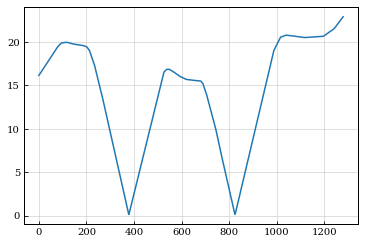

In [5]:
drone_data_path = drone_data_path
corr_data_path = "/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z"
dish_loc = [41.31899934, -72.92132019, 25] #[ 41.31900474, -72.92132617, 25.00000005]   

# Compute angles using the simplified function
drone_angles = drone_angles_for_corr_range_simple(
    dish_location=dish_loc,
    drone_file=drone_data_path,
    corr_data_directory=corr_data_path,
    start_file=99,
    stop_file=104,
    use_ctime=True,
    output='degrees'
)

# Preview first few angles
plt.plot(drone_angles)
len(drone_angles)

Drone Distance from Dish (meters):
  Min: 49.997
  Max: 53.433
  Mean: 51.568
  Std: 1.091


1024

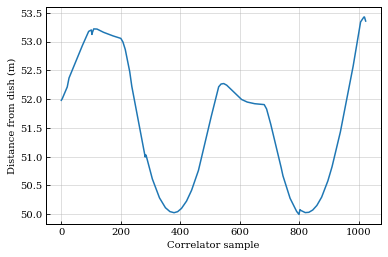

In [6]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import datetime
import h5py
import os
import pygeodesy

def drone_distance_for_corr_range_simple(dish_location, drone_file, corr_data_directory,
                                         start_file=0, stop_file=-1,
                                         use_ctime=False):
    """
    Compute absolute drone distance from a single dish location for a specific
    correlator file time range.

    Distance is computed using local Cartesian x, y, z coordinates:
        d = sqrt(x^2 + y^2 + z^2)

    Time handling matches the concat script: all times converted to float seconds
    since epoch.
    """

    # -----------------------
    # Step 1: Load correlator timestamps
    # -----------------------
    all_files = sorted([f for f in os.listdir(corr_data_directory) if ".lock" not in f])
    filenames = all_files[start_file:stop_file]
    if len(filenames) == 0:
        raise ValueError("No correlator files found in the specified range.")

    t_list = []
    for fname in filenames:
        with h5py.File(os.path.join(corr_data_directory, fname), 'r') as fd:
            if use_ctime:
                t_file = fd['index_map']['time']['ctime'][:].astype(float)
            else:
                t_file = 1e-9 * fd['index_map']['time']['irigb_time'][:].astype(float)
            t_list.append(t_file)

    t_corr_sec = np.concatenate(t_list).astype(float)

    # -----------------------
    # Step 2: Load drone CSV timestamps
    # -----------------------
    df = pd.read_csv(drone_file, low_memory=False)

    if 'datetime(utc)' in df.columns and 'time(millisecond)' in df.columns:
        t0 = pd.to_datetime(df['datetime(utc)'], utc=True).iloc[0]
        drone_times = np.array([
            (t0 + datetime.timedelta(milliseconds=x)).timestamp()
            for x in df['time(millisecond)']
        ])
    elif 'GPS:dateTimeStamp' in df.columns:
        drone_times = pd.to_datetime(
            df['GPS:dateTimeStamp'], utc=True
        ).map(lambda t: t.timestamp()).values
    else:
        raise KeyError("No recognizable time columns in drone file.")

    # -----------------------
    # Step 3: Mask drone data to correlator time range
    # -----------------------
    t_start_sec, t_stop_sec = t_corr_sec[0], t_corr_sec[-1]
    mask = (drone_times >= t_start_sec) & (drone_times <= t_stop_sec)
    if not mask.any():
        raise ValueError("No drone data falls within the correlator time range.")

    df = df.loc[mask].copy()
    drone_times = drone_times[mask]

    # -----------------------
    # Step 4: Extract drone positions
    # -----------------------
    if 'RTKdata:Lat_P' in df.columns:
        lat = df['RTKdata:Lat_P'].values
        lon = df['RTKdata:Lon_P'].values
        alt = df['RTKdata:Hmsl_P'].values
    elif 'GPS(0):Lat' in df.columns:
        lat = df['GPS(0):Lat'].values
        lon = df['GPS(0):Long'].values
        alt = df['GPS(0):heightMSL'].values
    elif 'GPS:Lat' in df.columns:
        lat = df['GPS:Lat'].values
        lon = df['GPS:Long'].values
        alt = df['GPS:heightMSL'].values
    elif 'latitude' in df.columns:
        lat = df['latitude'].values
        lon = df['longitude'].values
        if 'altitude(meters)' in df.columns:
            alt = df['altitude(meters)'].values
        elif 'altitude(feet)' in df.columns:
            alt = df['altitude(feet)'].values * 0.3048
        else:
            raise KeyError("No altitude column found in drone file.")
    else:
        raise KeyError("No recognizable latitude/longitude columns in drone file.")

    # Remove NaNs
    valid = ~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(alt)
    lat, lon, alt = lat[valid], lon[valid], alt[valid]
    drone_times = drone_times[valid]

    # -----------------------
    # Step 5: Convert to local Cartesian coordinates
    # -----------------------
    origin_lat, origin_lon, origin_alt = dish_location
    prime_origin = pygeodesy.EcefCartesian(
        latlonh0=origin_lat, lon0=origin_lon, height0=origin_alt
    )

    drone_xyz = np.zeros((len(lat), 3))
    for i in range(len(lat)):
        p = pygeodesy.ellipsoidalNvector.LatLon(
            lat[i], lon[i], height=alt[i]
        )
        drone_xyz[i] = prime_origin.forward(p).toVector()

    # -----------------------
    # Step 6: Absolute distance from dish
    # -----------------------
    x = drone_xyz[:, 0]
    y = drone_xyz[:, 1]
    z = drone_xyz[:, 2]

    drone_distance = np.sqrt(x**2 + y**2 + z**2)

    # -----------------------
    # Step 7: Interpolate distance to correlator timestamps
    # -----------------------
    distance_interp = np.interp(t_corr_sec, drone_times, drone_distance)

    # -----------------------
    # Step 8: Simple diagnostics
    # -----------------------
    print(
        "Drone Distance from Dish (meters):\n"
        f"  Min: {distance_interp.min():.3f}\n"
        f"  Max: {distance_interp.max():.3f}\n"
        f"  Mean: {distance_interp.mean():.3f}\n"
        f"  Std: {distance_interp.std():.3f}"
    )

    return distance_interp


# ------------------------------------------------------------------
# Usage
# ------------------------------------------------------------------
drone_data_path = drone_data_path
corr_data_path = "/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z"


drone_distance = drone_distance_for_corr_range_simple(
    dish_location=dish_loc,
    drone_file=drone_data_path,
    corr_data_directory=corr_data_path,
    start_file=99,
    stop_file=103,
    use_ctime=True
)

plt.plot(drone_distance)
plt.ylabel("Distance from dish (m)")
plt.xlabel("Correlator sample")
len(drone_distance)


Done!!!!!!!
getting autocorrelation magnitudes and phase
done getting pow_mag and pow_phase
(1024, 1024, 10)


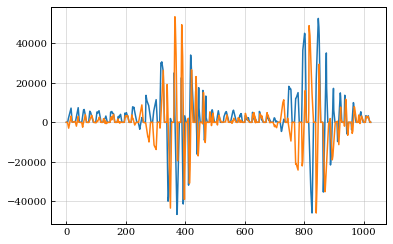

In [7]:
# Center Hovering
corr_data_path = '/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z/*'
file_path = corr_data_path
corr_data_s = read_corr_mode_h5(file_path, f_start=99, f_stop=103) #61
print("getting autocorrelation magnitudes and phase")
pow_mag_s, pow_phase_s = get_mag_phase(corr_data_s.vis)
print("done getting pow_mag and pow_phase")
sat_data = corr_data_s.sat.real # what is this paramater?
print(pow_mag_s.shape)

plt.plot(corr_data_s.vis.real[:,300,8])
plt.plot(corr_data_s.vis.imag[:,300,8])

In [8]:
import h5py

d = h5py.File('/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z/0088', 'r')

def show_all(name, obj):
    print("\nPATH:", name)

    if isinstance(obj, h5py.Group):
        print("TYPE: Group")

    if isinstance(obj, h5py.Dataset):
        print("TYPE: Dataset")
        print("shape:", obj.shape)
        print("dtype:", obj.dtype)

    # attributes
    if len(obj.attrs) > 0:
        print("ATTRIBUTES:")
        for k, v in obj.attrs.items():
            print("  ", k, "=", v)

d.visititems(show_all)


PATH: counts
TYPE: Dataset
shape: (256, 1024, 10)
dtype: uint32
ATTRIBUTES:
   axis = [b'time' b'freq' b'prod']

PATH: index_map
TYPE: Group

PATH: index_map/freq
TYPE: Dataset
shape: (1024,)
dtype: [('centre', '<f8'), ('width', '<f8')]

PATH: index_map/prod
TYPE: Dataset
shape: (10,)
dtype: [('input_a', '<u2'), ('input_b', '<u2')]

PATH: index_map/time
TYPE: Dataset
shape: (256,)
dtype: [('integ_number', '<u4'), ('fpga_count', '<u8'), ('irigb_time', '<u8'), ('ctime', '<f8')]

PATH: sat
TYPE: Dataset
shape: (256, 1024, 10)
dtype: complex64
ATTRIBUTES:
   axis = [b'time' b'freq' b'prod']

PATH: vis
TYPE: Dataset
shape: (256, 1024, 10)
dtype: complex128
ATTRIBUTES:
   axis = [b'time' b'freq' b'prod']


In [9]:
d['index_map']['time']['irigb_time']

array([944892805120, 944934748160, 944976691200, 945018634240,
       945060577280, 945102520320, 945144463360, 945186406400,
       945228349440, 945270292480, 945312235520, 945354178560,
       945396121600, 945438064640, 945480007680, 945521950720,
       945563893760, 945605836800, 945647779840, 945689722880,
       945731665920, 945773608960, 945815552000, 945857495040,
       945899438080, 945941381120, 945983324160, 946025267200,
       946067210240, 946109153280, 946151096320, 946193039360,
       946234982400, 946276925440, 946318868480, 946360811520,
       946402754560, 946444697600, 946486640640, 946528583680,
       946570526720, 946612469760, 946654412800, 946696355840,
       946738298880, 946780241920, 946822184960, 946864128000,
       946906071040, 946948014080, 946989957120, 947031900160,
       947073843200, 947115786240, 947157729280, 947199672320,
       947241615360, 947283558400, 947325501440, 947367444480,
       947409387520, 947451330560, 947493273600, 947535

In [10]:
np.shape(corr_data_s.vis)

print(corr_data_s.vis[:,:,8])

[[-131072.+0.j       0.+0.j       0.+0.j ...       0.+0.j       0.+0.j
        0.+0.j]
 [-131072.+0.j       0.+0.j       0.+0.j ...       0.+0.j       0.+0.j
        0.+0.j]
 [-131072.+0.j       0.+0.j       0.+0.j ...       0.+0.j       0.+0.j
        0.+0.j]
 ...
 [-131072.+0.j       0.+0.j       0.+0.j ...       0.+0.j       0.+0.j
        0.+0.j]
 [-131072.+0.j       0.+0.j       0.+0.j ...       0.+0.j       0.+0.j
        0.+0.j]
 [-131072.+0.j       0.+0.j       0.+0.j ...       0.+0.j       0.+0.j
        0.+0.j]]


(1024, 1024, 10)
Done!!!!!!!
(256, 1024, 10)
(1024, 1024)


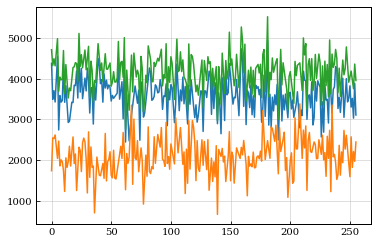

In [11]:
print(np.shape(corr_data_s.vis))

starting_times = read_corr_mode_h5(file_path, f_start=0, f_stop=1)

reals = starting_times.vis.real
imags = starting_times.vis.imag

complexes = reals + 1j * imags

print(np.shape(complexes))

plt.plot(reals[:400,300,8])
plt.plot(imags[:400,300,8])
plt.plot(np.abs(complexes[:400,300,8]))

real_offset = np.median(reals[:400, :, 8], axis=0)
imag_offset = np.median(imags[:400, :, 8], axis=0)
complexes_offset = real_offset + 1j * imag_offset

cross_channel = corr_data_s.vis[:,:,8]

print(np.shape(cross_channel))


n_time, n_freq = cross_channel.shape

corr_data_c = np.zeros((n_time, n_freq), dtype=complex)

for i in range(n_freq):
    corr_data_c[:, i] = cross_channel[:, i] - complexes_offset[i]
    
#corr_data_c is just like corr_data_s except just for one channel 


pow_mag_c, pow_phase_c = get_mag_phase(corr_data_c)

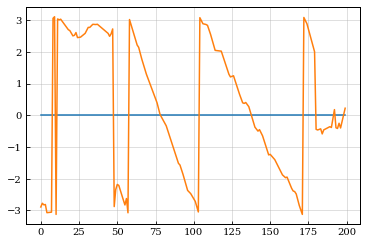

In [12]:
plt.plot(np.angle(cross_channel[1,200:400]))
plt.plot(np.angle(corr_data_c[1,200:400]))

In [13]:
#dir(corr_data_s)
#print(corr_data_s.time)
from datetime import datetime

# Get the list of timestamps
time_tuples = corr_data_s.time

# Convert the last element of each tuple to datetime objects
converted_times = [datetime.utcfromtimestamp(t[-1]) for t in time_tuples]

# Print only the first and last timestamps
print("Start time:", converted_times[0].strftime("%Y-%m-%d %H:%M:%S"))
print("End time:  ", converted_times[-1].strftime("%Y-%m-%d %H:%M:%S"))



Start time: 2025-04-12 19:59:17
End time:   2025-04-12 20:00:00


(array([20190.83287037, 20190.83292824, 20190.83298611, 20190.83304398,
        20190.83310185, 20190.83315972, 20190.83321759, 20190.83327546,
        20190.83333333]),
 [Text(20190.83287037037, 0, '19:59:20'),
  Text(20190.83292824074, 0, '19:59:25'),
  Text(20190.832986111112, 0, '19:59:30'),
  Text(20190.83304398148, 0, '19:59:35'),
  Text(20190.83310185185, 0, '19:59:40'),
  Text(20190.83315972222, 0, '19:59:45'),
  Text(20190.833217592593, 0, '19:59:50'),
  Text(20190.833275462963, 0, '19:59:55'),
  Text(20190.833333333332, 0, '20:00:00')])

<Figure size 2016x1800 with 0 Axes>

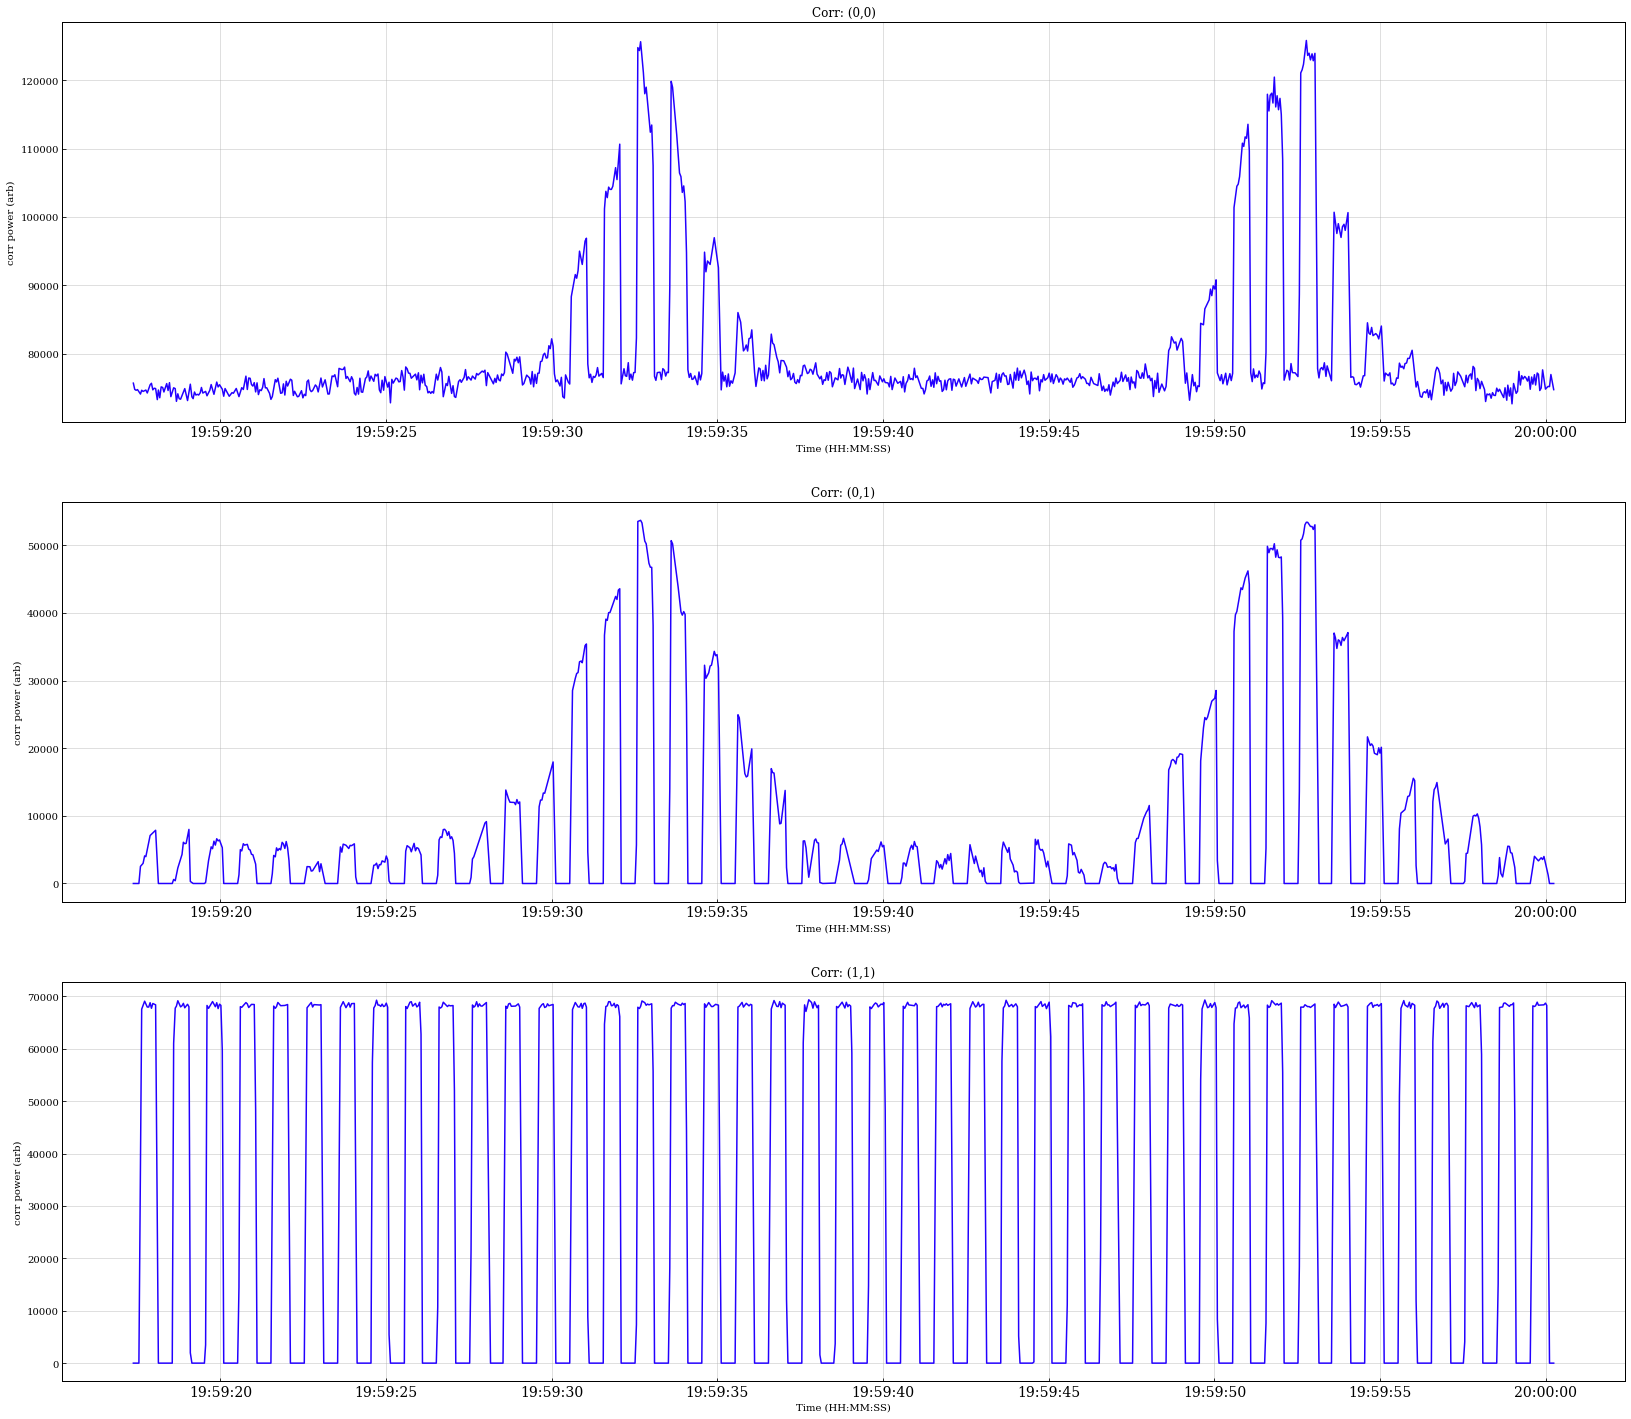

In [14]:
from matplotlib import dates as mdates
from datetime import datetime

plt.figure(figsize=[28,25])

colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
plt.figure(figsize=[28,25])
fbin=300
k=50
tmin,tmax=[0,-1]
# Convert timestamps just once
times = [datetime.utcfromtimestamp(t[-1]) for t in corr_data_s.time]
times = times[tmin:tmax]  # apply slicing like the data

# Plot
plt.subplot(3,1,1)
plt.plot(times, pow_mag_s[tmin:tmax, fbin, 7], c=colorsarr[fbin])
plt.title(f"Corr: (0,0)")
plt.xlabel("Time (HH:MM:SS)")
plt.ylabel("corr power (arb)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
plt.xticks(fontsize=14)

plt.subplot(3,1,2)
plt.plot(times, pow_mag_s[tmin:tmax, fbin, 8], c=colorsarr[fbin])
plt.title(f"Corr: (0,1)")
plt.xlabel("Time (HH:MM:SS)")
plt.ylabel("corr power (arb)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
plt.xticks(fontsize=14)

plt.subplot(3,1,3)
plt.plot(times, pow_mag_s[tmin:tmax, fbin, 9], c=colorsarr[fbin])
plt.title(f"Corr: (1,1)")
plt.xlabel("Time (HH:MM:SS)")
plt.ylabel("corr power (arb)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
plt.xticks(fontsize=14)


<Figure size 2016x1800 with 0 Axes>

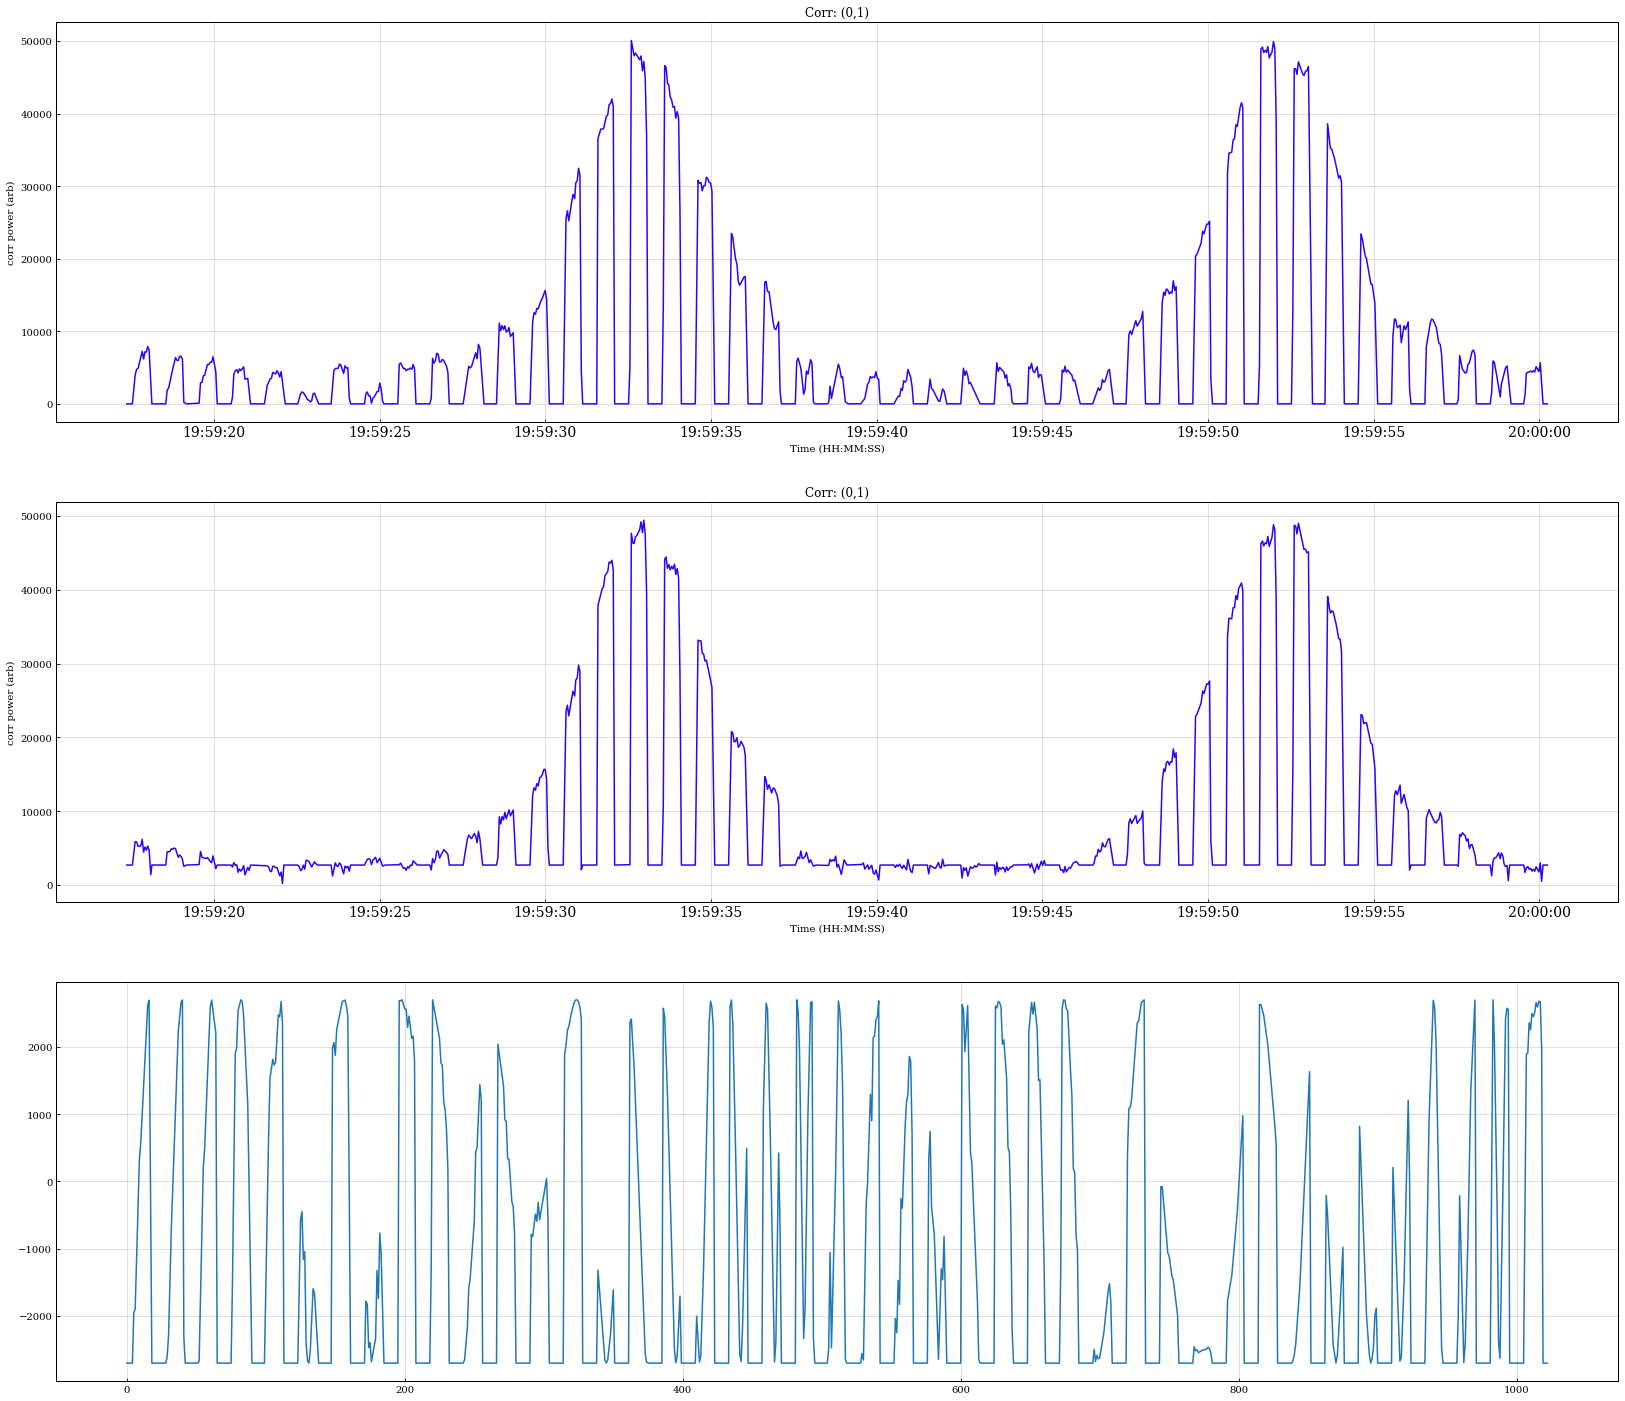

In [15]:
from matplotlib import dates as mdates
from datetime import datetime

plt.figure(figsize=[28,25])

colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
plt.figure(figsize=[28,25])
fbin=315
k=50
tmin,tmax=[0,-1]
# Convert timestamps just once
times = [datetime.utcfromtimestamp(t[-1]) for t in corr_data_s.time]
times = times[tmin:tmax]  # apply slicing like the data

# Plot
plt.subplot(3,1,1)
plt.plot(times, pow_mag_s[tmin:tmax, fbin, 8], c=colorsarr[fbin])
plt.title(f"Corr: (0,1)")
plt.xlabel("Time (HH:MM:SS)")
plt.ylabel("corr power (arb)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
plt.xticks(fontsize=14)

plt.subplot(3,1,2)
plt.plot(times, pow_mag_c[tmin:tmax, fbin], c=colorsarr[fbin])
plt.title(f"Corr: (0,1)")
plt.xlabel("Time (HH:MM:SS)")
plt.ylabel("corr power (arb)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
plt.xticks(fontsize=14)


plt.subplot(3,1,3)
plt.plot(pow_mag_s[tmin:tmax, fbin, 8] - pow_mag_c[tmin:tmax, fbin])

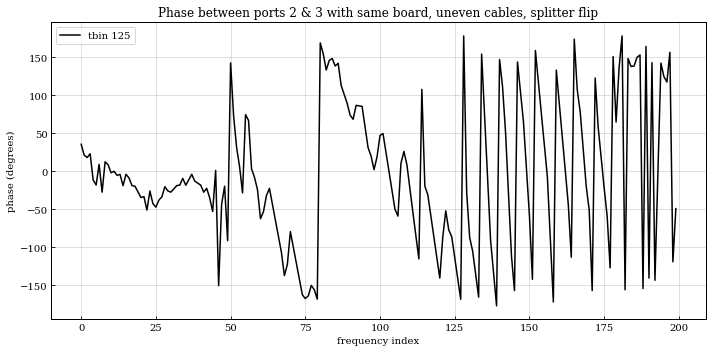

In [16]:
def plot_freq_channel_corr_data(pow_mag,timestamp=125, start_freq_ind=200, stop_freq_ind=400, corr_indices=[8]):
    fig= plt.figure(figsize=(10, 5))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            ax = plt.subplot(dim1, dim2, index + 1)
            ax = plt.subplot(111)
            plt.title('Phase between ports 2 & 3 with same board, uneven cables, splitter flip')
            ax.plot(pow_mag[timestamp,start_freq_ind:stop_freq_ind, corr_index], c=colorsarr[5], label='tbin '+str(timestamp))
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
            ax.legend()
            plt.xlabel(f"frequency index")
            plt.ylabel(f"phase (degrees)")
    #plt.suptitle(f"Correlated noise phase")
    plt.tight_layout()
    
    return pow_mag[timestamp,start_freq_ind:stop_freq_ind, corr_index]

corr_phase_center = plot_freq_channel_corr_data(pow_phase_s)

In [17]:
# #selecting ons and offs

# #Will's function for identifying pulse sections


# def Extract_Source_Pulses(self,Period=0.9999e6,Dutycycle=0.5e6,t_bounds=[0,-1],f_ind=300,minmaxpercents=[0.0001,100]):
#     ## If we don't have any variables, then we haven't loaded a yaml yet... and must run the function:
#         pow_mag, pow_phase = get_mag_phase(self.vis)
#         ## Create Switch Signal
#         self.pulse_period=Period
#         self.pulse_dutycycle=Dutycycle
#         delta_time = np.diff(self.time["irigb_time"])[1]*1e-9
#         concat_duration=int(np.ceil(delta_time*len((self.vis)))) #actual full time in seconds
#         time_s,time_dt,switch=tu.Pulsed_Data_Waveform(total_duration=concat_duration,period=self.pulse_period,duty_cycle_on=self.pulse_dutycycle)
#         ## Create t_offset range (1 period) and Pearson_r vars:
#         t_offset_dist=np.arange(-1.0*self.pulse_period*1e-6,0.0,0.001)
#         n_channels = 3
#         Pr_arr=np.NaN*np.ones((n_channels,t_offset_dist.shape[0]))
#         Pr_max_ind_per_channel=np.NaN*np.ones(n_channels) 
#         Pr_max_t_0_per_channel=np.NaN*np.ones(n_channels)
#         # Given parameters
#         num_bins = len(pow_mag[:,f_ind,1])
#         time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
#         # Create the array of time values
#         t_full = np.arange(num_bins) * time_bin_width
#         #t_full=np.array([(m-self.t_arr_datetime[0]).total_seconds() for m in self.t_arr_datetime[:]])

    
#         ## Loop over channels to find/plot a time offset solution with some clever fitting:
#         fig1,ax1=plt.subplots(nrows=1,ncols=1,figsize=(16,4))
        
#         for i in range(n_channels):
#             ## If we use a mean subtracted data cut we can find where power exceeds zero to find signal
#             minsubdata=self.vis[:,f_ind,i]-np.percentile(self.vis[:,f_ind,i],minmaxpercents[0])
#             normminsubdata=minsubdata/np.percentile(minsubdata,minmaxpercents[1])
#             clipnormminsubdata=normminsubdata.clip(0,1)
#             stepped_func=interp1d(t_full,clipnormminsubdata,kind='previous',fill_value='extrapolate')
#             sniparr=np.where(time_s[np.where(time_s<=t_full[t_bounds[1]])[0]]>=t_full[t_bounds[0]])[0]
#             t_restrict=np.intersect1d(np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],sniparr)
            
#             #plt.plot(stepped_func(time_s[t_restrict]))
#             #shiftedswitch=np.interp(time_s,time_s+t_offset_dist[265],switch)
#             #plt.plot(shiftedswitch[t_restrict]+0.5)
#             #print(pearsonr(stepped_func(time_s[t_restrict]).real,(shiftedswitch[t_restrict]+0.5))[0])
            
            
#             ## Loop over all time offsets in t_offset_dist to find maximum correlation between squarewave and data:
#             for j,t_offset in enumerate(t_offset_dist):
#                 shiftedswitch=np.interp(time_s,time_s+t_offset,switch)
#                 try:
#                     Pr_arr[i,j]=pearsonr(stepped_func(time_s[t_restrict]).real,(shiftedswitch[t_restrict]))[0]
#                 except ValueError:
#                     Pr_arr[i,j]=np.NAN
#                     print(str(j)+" failed: " +str(t_offset))
            
            
#             ax1.plot(t_offset_dist,Pr_arr[i,:],'.',label=str(i))
           
            
#             try:
#                 maxPrind=np.where(Pr_arr[i,:]==np.nanmax(Pr_arr[i,:]))[0][0]
                
#                 ax1.plot(t_offset_dist[maxPrind],Pr_arr[i,maxPrind],'ro')

                
#                 Pr_max_ind_per_channel[i]=maxPrind
#                 Pr_max_t_0_per_channel[i]=t_offset_dist[maxPrind]
#             except IndexError:
#                 Pr_max_ind_per_channel[i]=np.NAN
#                 Pr_max_t_0_per_channel[i]=np.NAN
#         self.t_delta_pulse=Pr_max_t_0_per_channel[0]   
#         ax1.axvline(self.t_delta_pulse,label="selected t_offset")
#         ax1.legend(loc=1)
#         plt.tight_layout()
#         print("Maximum Pearson_R Correlations between data and square wave function:")
#         print("  --> t_indices = {}".format(Pr_max_ind_per_channel))
#         print("  --> t_deltas = {}".format(np.around(Pr_max_t_0_per_channel,decimals=3)))
#         print("Selecting square wave function time offset:")
#         print("  --> t_delta_pulse = {:.10f}".format(self.t_delta_pulse))
    
#         #if self.save_traceback==True:
#             #savefig(self.Output_Directory+self.Output_Prefix+"_t_delta_pulse_Pearson_R.png")
#         #if self.save_traceback==False:
#             #pass
#     #elif self.traceback==False:
#         #pass
        
        
#         t_arr_datetime = t_full 
#     ## Interpolate the switching function with the concat timestamps using either input or found t_delta_pulse:
#         num_bins = len(pow_mag[:,f_ind,1])
#         time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
#         # Create the array of time values
#         t_for_interp_out=np.arange(num_bins) * time_bin_width #defining same as t_full
#         t_for_interp_in=np.array([m.total_seconds() for m in time_dt])
#         switch_interp_f=np.interp(t_for_interp_out,t_for_interp_in+self.t_delta_pulse,switch)
#         self.switch_signal=switch
#         self.switch_time=t_for_interp_in
#         self.switch_signal_interp=switch_interp_f
#         #print(switch_interp_f)
#         ## Once we have our time offset, we must extract indices where the source is on/off/rising:
#         self.inds_span=np.union1d(list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),\
#                                   np.intersect1d(np.where(1>switch_interp_f),np.where(switch_interp_f>0))).tolist()
    
#         self.inds_on=list(set(np.where(switch_interp_f==1)[0])-set(self.inds_span))
#         self.inds_off=list(set(np.where(switch_interp_f==0)[0])-set(self.inds_span))
        
#         # Add this code snippet after interpolating switch_interp_f in Extract_Source_Pulses function


#         #print("Inds span: " + str(self.inds_span))
#         #print("Inds on: " + str(self.inds_on))
#         #print("Inds off: " + str(self.inds_off))



#     ## Each of these lists of indices should also have no overlap. Let's print to see:
#         print("Finding relevant pulsing indices and checking for overlaps:")
#         print("  --> on/off ind intersection:",np.intersect1d(self.inds_on,self.inds_off))
#         print("  --> on/span ind intersection:",np.intersect1d(self.inds_on,self.inds_span))
#         print("  --> off/span ind intersection:",np.intersect1d(self.inds_off,self.inds_span))

    
#         channel_indicies = [7,8,9]
#         on_avgs = []
#         on_stds=[]
#         fig3=plt.figure(figsize=(16,int(4*n_channels/2)))
        
#         for i in range(n_channels):
#             all_data = pow_mag[:,f_ind,channel_indicies[i]]
            
            
#             # Assume self.inds_on and all_data are already defined

#             # Calculate z-scores
#             #z_scores = np.abs((all_data[self.inds_on] - np.mean(all_data[self.inds_on])) / np.mean(all_data[self.inds_on]))
#             #print(z_scores)
#             # Identify outliers
#             #outlier_indices = np.where(z_scores > .3)[0]
#             # Print outliers if any
#             #print("Outlier indices:", outlier_indices)  # Check the values of outlier_indices
#             #print("Outlier Z values:", z_scores[outlier_indices])
#             # Remove outliers
#             #inds_on_clean = np.delete(self.inds_on, outlier_indices)
#             # Calculate mean and std with cleaned indices
#             on_avgs.append(np.mean(all_data[self.inds_on]))
#             on_stds.append(np.std(all_data[self.inds_on]))

            
#             ax=fig3.add_subplot(n_channels,1,i+1)
#             ax.plot(t_arr_datetime[:],all_data[:],label='data')
#             ax.scatter(t_arr_datetime[self.inds_on],all_data[self.inds_on],label='on',color='red',s=10)
#             ax.scatter(t_arr_datetime[self.inds_off],all_data[self.inds_off],label='off',color='green',s=10)
#             ax.scatter(t_arr_datetime[self.inds_span],all_data[self.inds_span],label='span',color='blue',s=10)
#             #ax.semilogy(t_arr_datetime[:],self.vis[:,f_ind,i],'k.',label='all')
#             #plt.plot(t_arr_datetime[:],self.vis[:,f_ind,i],'k.',label='all')
#             #ax.semilogy(t_arr_datetime[self.inds_on],self.vis[self.inds_on,f_ind,i],'.',label='on')
#             #ax.semilogy(t_arr_datetime[self.inds_off],self.vis[self.inds_off,f_ind,i],'.',label='off')
#             #ax.semilogy(t_arr_datetime[self.inds_span],self.vis[self.inds_span,f_ind,i],'x',label='span')
#             #ax.semilogy(t_arr_datetime[:],(np.nanmax(self.vis[self.inds_on,f_ind,i])*switch_interp_f)+np.nanmin(self.vis[self.inds_on,f_ind,i]),'--',alpha=0.5,label='switch, t_offset={:.2f}'.format(self.t_delta_pulse))
#             ax.set_ylabel("Log Power Received [$ADU^2$]")
#             ax.set_xlabel("Datetime")
#             #ax.set_title("Channel {}".format(self.chmap[i]))
#             ax.legend(loc=3)
#             #ax.set_xlim(t_arr_datetime[t_bounds[0]],t_arr_datetime[t_bounds[1]])
            
#         # Visualize alignment of switch_interp_f with actual data
#         fig_align, ax_align = plt.subplots(figsize=(12, 6))
#         ax_align.plot(t_arr_datetime, all_data, label='Actual Data')
#         ax_align.plot(t_arr_datetime, switch_interp_f * np.nanmax(all_data), label='Interpolated Switch')
#         ax_align.set_xlabel('Datetime')
#         ax_align.set_ylabel('Data / Interpolated Switch')
#         ax_align.set_title('Alignment of Interpolated Switch with Actual Data')
#         ax_align.legend()
#         plt.tight_layout()
#         plt.show()
        
#         print("Frequency bin: "+str(f_ind))

#         return on_avgs, on_stds, self.inds_on, self.inds_off, self.inds_span
    
    
    
#     #Grabbing all "On" indicies (instead of just saving the means/stds) and saving to csv

# fbin = 300    
    

# # Path to the master CSV file
# master_csv_file = 'on_inds_2.5_ms_pass_0425_f'+str(fbin)+'.csv'

# # Define headers for the CSV file
# fieldnames = ['Angle', 'On_Inds']

# # Function to initialize or create the CSV file with headers
# def initialize_csv_file():
#     if not os.path.exists(master_csv_file):
#         with open(master_csv_file, mode='w', newline='') as file:
#             writer = csv.DictWriter(file, fieldnames=fieldnames)
#             writer.writeheader()

# # Function to save avgs and stds to the CSV file
# def corr_on_inds(corr_data,period=0.9998e6,duty_cycle=0.5e6,file_path=file_path,seed=0):
#     avgs, stds, on_inds, off_inds, span = Extract_Source_Pulses(corr_data,Period=period,Dutycycle=duty_cycle,f_ind=fbin)
    
#     # Read existing data from CSV file
#     rows_to_write = []
#     if os.path.exists(master_csv_file):
#         print(master_csv_file)
#         with open(master_csv_file, mode='r', newline='') as file_read:
#             reader = csv.DictReader(file_read)
#             rows = list(reader)
            
#             # Check if there is already a row for this angle; if so, update it
#             angle_exists = False
#             for row in rows:
#                 if row['Angle'] == str(seed):
#                     row['On_Inds'] = on_inds
#                     angle_exists = True
#                 rows_to_write.append(row)
    
#     # If angle doesn't exist, add a new row
#     if not angle_exists:
#         rows_to_write.append({
#             'Angle': str(seed),
#             'On_Inds': on_inds
#         })
    
#     # Write all rows (updated or new) back to the CSV file
#     with open(master_csv_file, mode='w', newline='') as file_write:
#         writer = csv.DictWriter(file_write, fieldnames=fieldnames)
#         writer.writeheader()  # Write headers
#         writer.writerows(rows_to_write)

# # Initialize or create the CSV file with headers
# initialize_csv_file()

# # Example usage:
# # corr_data_stats(0)  # Call this function as needed with different angles


# corr_on_inds(corr_data_s)

    
    

In [18]:
import ast

fbin =300

on_inds = []
csv_filename = 'on_inds_2.5_ms_pass_0425_f'+str(fbin)+'.csv'

# Read CSV file
with open(csv_filename, 'r') as csvfile:
    csvreader = csv.reader(csvfile)
    next(csvreader)  # Skip header if it exists
    for row in csvreader:
        #angles.append(row[0])  # Assuming the first column is angle values
        on_inds.append(ast.literal_eval(row[1]))  # Convert string to list


In [19]:
def unwrap(phase_data):
    # Convert phase data to radians and unwrap
    unwrapped_data = np.unwrap(np.radians(phase_data))
    
    # Convert back to degrees
    unwrapped_data = np.degrees(unwrapped_data)
    
    # Align unwrapped data with the first point of the wrapped data
    adjustment = phase_data[-1] - unwrapped_data[-1]
    unwrapped_data += adjustment
    
    return unwrapped_data

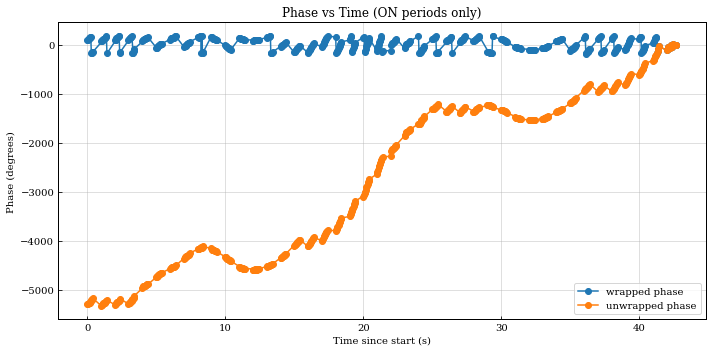

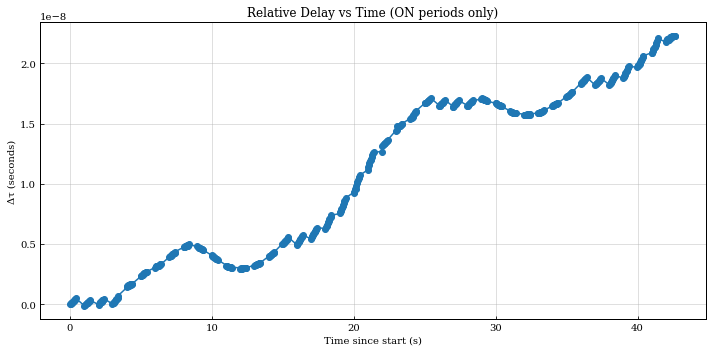

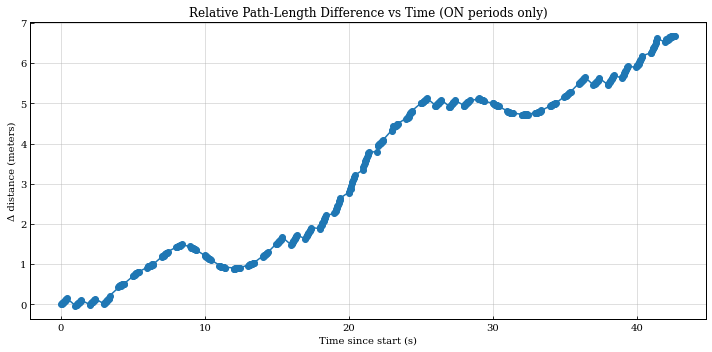

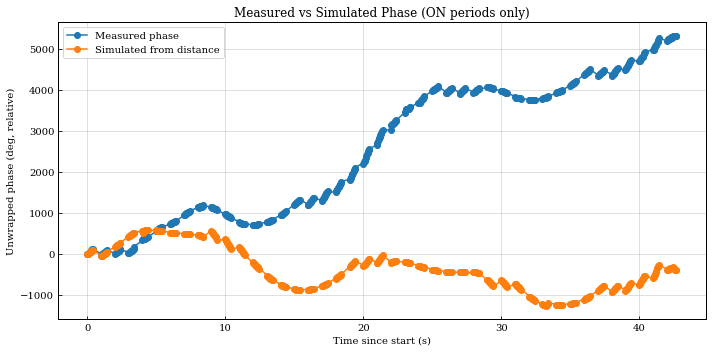

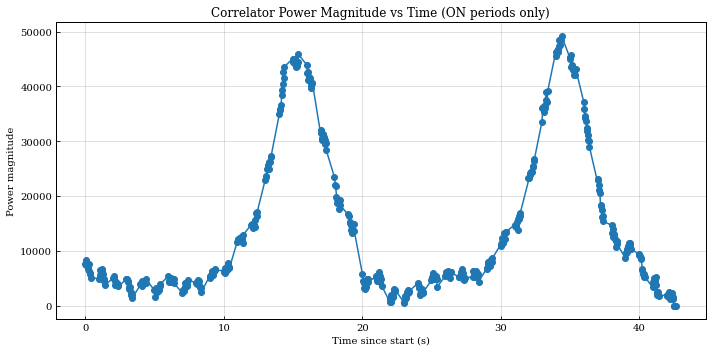

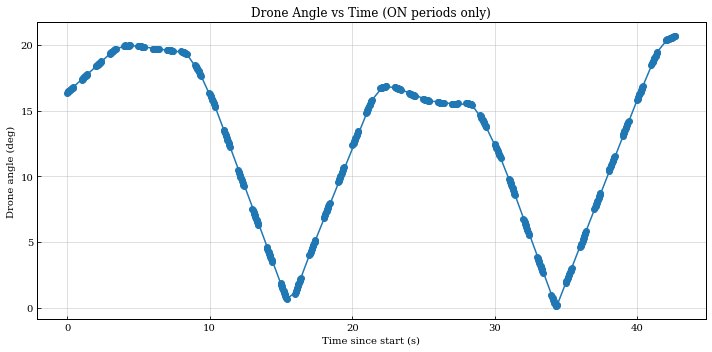

In [20]:
from astropy.constants import c
from datetime import datetime

c = c.value  # speed of light in m/s

# -------------------------------
# Assumptions / inputs
# -------------------------------

fbin = 350
corr_index = 8
t_start = 0
t_stop  = -1

# -------------------------------
# Handle t_stop = -1 safely
# -------------------------------
n_time = pow_phase_s.shape[0]

if t_stop == -1 or t_stop > n_time:
    t_stop = n_time

# -------------------------------
# Convert frequency bin → Hz
# -------------------------------
f_Hz = corr_data_s.freq[fbin][0] * 1e6

# -------------------------------
# Determine ON indices within selected range
# -------------------------------
on_inds = np.asarray(on_inds)

mask = (on_inds >= t_start) & (on_inds < t_stop)
on_inds_sel = on_inds[mask]

# Guard against empty selection
if len(on_inds_sel) == 0:
    raise ValueError("No ON indices found in the selected time range.")

# Indices relative to t_start
rel_inds = on_inds_sel - t_start

# -------------------------------
# Build real (gappy) time axis
# -------------------------------
times_dt_all = [datetime.utcfromtimestamp(t[-1]) for t in corr_data_s.time]
times_dt_sel = [times_dt_all[i] for i in on_inds_sel]

times_sec = np.array([
    (t - times_dt_sel[0]).total_seconds() for t in times_dt_sel
])

# -------------------------------
# Extract phase vs time (ON samples only)
# -------------------------------
phase_all = pow_phase_s[t_start:t_stop, fbin, corr_index]
phase_time = phase_all[rel_inds]

# -------------------------------
# Robust unwrap
# -------------------------------
def unwrap(phase_data):
    if len(phase_data) == 0:
        return phase_data

    unwrapped = np.unwrap(np.radians(phase_data))
    unwrapped = np.degrees(unwrapped)

    # Align end-point to wrapped data
    adjustment = phase_data[-1] - unwrapped[-1]
    return unwrapped + adjustment

phase_time_unwrap = unwrap(phase_time)
phase_time_unwrap_rad = np.radians(phase_time_unwrap)

# ======================================================
# Diagnostic plot: wrapped vs unwrapped phase
# ======================================================
plt.figure(figsize=(10, 5))
plt.plot(times_sec, phase_time, marker='o', label='wrapped phase')
plt.plot(times_sec, phase_time_unwrap, marker='o', label='unwrapped phase')
plt.xlabel("Time since start (s)")
plt.ylabel("Phase (degrees)")
plt.title("Phase vs Time (ON periods only)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# -------------------------------
# Phase → delay → distance (measured)
# -------------------------------
tau_t = phase_time_unwrap_rad / (2 * np.pi * f_Hz)
dist_t = tau_t * c

tau_t_rel  = tau_t  - tau_t[0]
dist_t_rel = dist_t - dist_t[0]

# -------------------------------
# Plot delay vs time
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(times_sec, tau_t_rel, marker='o')
plt.xlabel("Time since start (s)")
plt.ylabel("Δτ (seconds)")
plt.title("Relative Delay vs Time (ON periods only)")
plt.grid(True)
plt.tight_layout()

# -------------------------------
# Plot distance vs time
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(times_sec, dist_t_rel, marker='o')
plt.xlabel("Time since start (s)")
plt.ylabel("Δ distance (meters)")
plt.title("Relative Path-Length Difference vs Time (ON periods only)")
plt.grid(True)
plt.tight_layout()

# ======================================================
# Simulated phase from drone distance (forward model)
# ======================================================
drone_distance = np.asarray(drone_distance)
drone_dist_sel = drone_distance[on_inds_sel]

tau_sim = drone_dist_sel / c
phase_sim_rad = 2 * np.pi * f_Hz * tau_sim
phase_sim_deg = np.degrees(phase_sim_rad)

# Wrap to [-180, 180)
phase_sim_wrapped = (phase_sim_deg + 180) % 360 - 180

# Unwrap using same routine
phase_sim_unwrap = unwrap(phase_sim_wrapped)

# Make relative for comparison
phase_sim_unwrap -= phase_sim_unwrap[0]
phase_time_unwrap_rel = phase_time_unwrap - phase_time_unwrap[0]

# -------------------------------
# Plot measured vs simulated phase
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(times_sec, phase_time_unwrap_rel,
         marker='o', label='Measured phase')
plt.plot(times_sec, phase_sim_unwrap,
         marker='o', label='Simulated from distance')
plt.xlabel("Time since start (s)")
plt.ylabel("Unwrapped phase (deg, relative)")
plt.title("Measured vs Simulated Phase (ON periods only)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# -------------------------------
# Extract power magnitude (ON samples only)
# -------------------------------
pow_mag_all = pow_mag_s[t_start:t_stop, fbin, corr_index]
pow_mag_sel = pow_mag_all[rel_inds]

plt.figure(figsize=(10, 5))
plt.plot(times_sec, pow_mag_sel, marker='o')
plt.xlabel("Time since start (s)")
plt.ylabel("Power magnitude")
plt.title("Correlator Power Magnitude vs Time (ON periods only)")
plt.grid(True)
plt.tight_layout()

# -------------------------------
# Extract drone angles (ON samples only)
# -------------------------------
drone_angles = np.asarray(drone_angles)
drone_angles_sel = drone_angles[on_inds_sel]

plt.figure(figsize=(10, 5))
plt.plot(times_sec, drone_angles_sel, marker='o')
plt.xlabel("Time since start (s)")
plt.ylabel("Drone angle (deg)")
plt.title("Drone Angle vs Time (ON periods only)")
plt.grid(True)
plt.tight_layout()


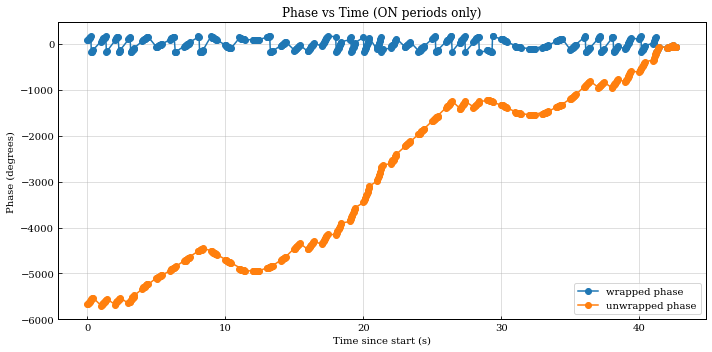

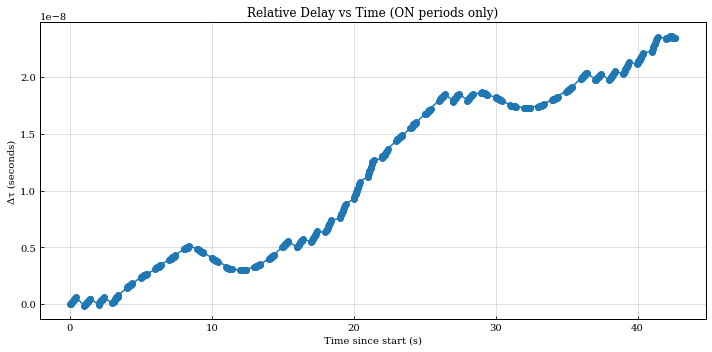

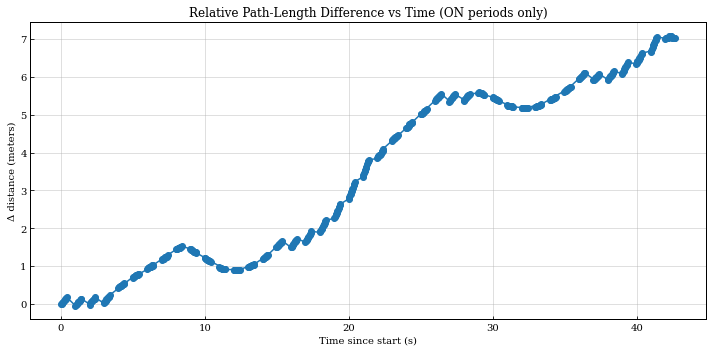

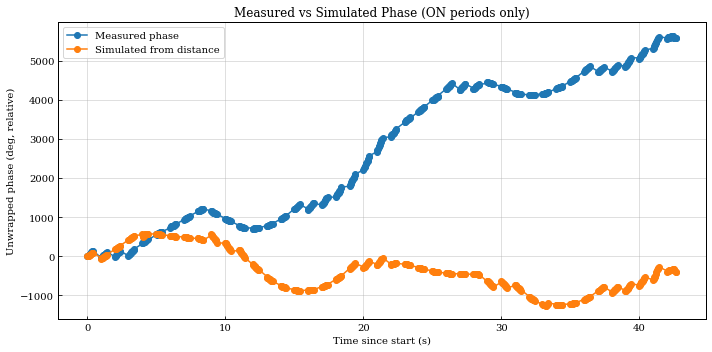

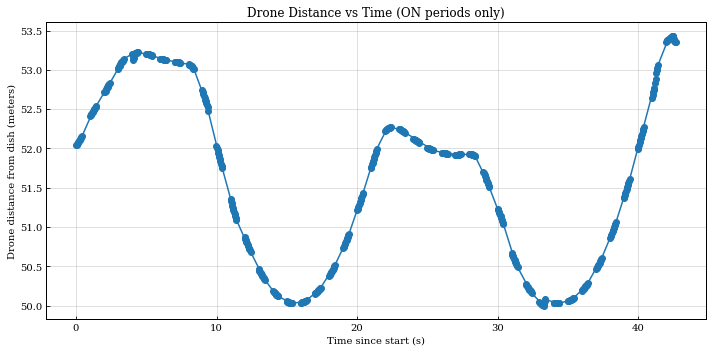

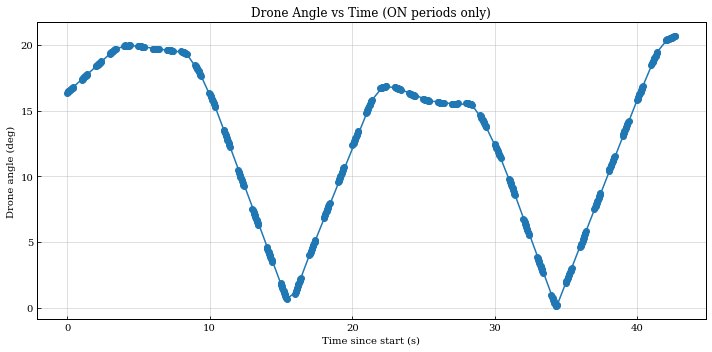

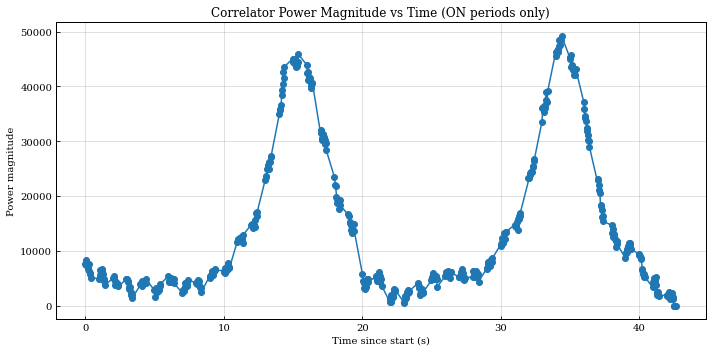

In [21]:
from astropy.constants import c
from datetime import datetime

c = c.value  # speed of light in m/s

# -------------------------------
# Assumptions / inputs
# -------------------------------
fbin = 350
corr_index = 8
t_start = 0
t_stop  = -1

# -------------------------------
# Handle t_stop = -1 safely
# -------------------------------
n_time = pow_phase_c.shape[0]

if t_stop == -1 or t_stop > n_time:
    t_stop = n_time

# -------------------------------
# Convert frequency bin → Hz
# -------------------------------
f_Hz = corr_data_s.freq[fbin][0] * 1e6

# -------------------------------
# Determine ON indices within selected range
# -------------------------------
on_inds = np.asarray(on_inds)

mask = (on_inds >= t_start) & (on_inds < t_stop)
on_inds_sel = on_inds[mask]

# Guard against empty selection
if len(on_inds_sel) == 0:
    raise ValueError("No ON indices found in the selected time range.")

# Indices relative to t_start
rel_inds = on_inds_sel - t_start

# -------------------------------
# Build real (gappy) time axis
# -------------------------------
times_dt_all = [datetime.utcfromtimestamp(t[-1]) for t in corr_data_s.time]
times_dt_sel = [times_dt_all[i] for i in on_inds_sel]

times_sec = np.array([
    (t - times_dt_sel[0]).total_seconds() for t in times_dt_sel
])

# -------------------------------
# Extract phase vs time (ON samples only)
# -------------------------------
phase_all = pow_phase_c[t_start:t_stop, fbin]
phase_time = phase_all[rel_inds]

# -------------------------------
# Robust unwrap
# -------------------------------
def unwrap(phase_data):
    if len(phase_data) == 0:
        return phase_data

    unwrapped = np.unwrap(np.radians(phase_data))
    unwrapped = np.degrees(unwrapped)

    # Align end-point to wrapped data
    adjustment = phase_data[-1] - unwrapped[-1]
    return unwrapped + adjustment

phase_time_unwrap = unwrap(phase_time)
phase_time_unwrap_rad = np.radians(phase_time_unwrap)

# ======================================================
# Diagnostic plot: wrapped vs unwrapped phase
# ======================================================
plt.figure(figsize=(10, 5))
plt.plot(times_sec, phase_time, marker='o', label='wrapped phase')
plt.plot(times_sec, phase_time_unwrap, marker='o', label='unwrapped phase')
plt.xlabel("Time since start (s)")
plt.ylabel("Phase (degrees)")
plt.title("Phase vs Time (ON periods only)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# -------------------------------
# Phase → delay → distance (measured)
# -------------------------------
tau_t = phase_time_unwrap_rad / (2 * np.pi * f_Hz)
dist_t = tau_t * c

tau_t_rel  = tau_t  - tau_t[0]
dist_t_rel = dist_t - dist_t[0]

# -------------------------------
# Plot delay vs time
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(times_sec, tau_t_rel, marker='o')
plt.xlabel("Time since start (s)")
plt.ylabel("Δτ (seconds)")
plt.title("Relative Delay vs Time (ON periods only)")
plt.grid(True)
plt.tight_layout()

# -------------------------------
# Plot distance vs time
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(times_sec, dist_t_rel, marker='o')
plt.xlabel("Time since start (s)")
plt.ylabel("Δ distance (meters)")
plt.title("Relative Path-Length Difference vs Time (ON periods only)")
plt.grid(True)
plt.tight_layout()

# ======================================================
# Simulated phase from drone distance (forward model)
# ======================================================
drone_distance = np.asarray(drone_distance)
drone_dist_sel = drone_distance[on_inds_sel]

tau_sim = drone_dist_sel / c
phase_sim_rad = 2 * np.pi * f_Hz * tau_sim
phase_sim_deg = np.degrees(phase_sim_rad)

# Wrap to [-180, 180)
phase_sim_wrapped = (phase_sim_deg + 180) % 360 - 180

# Unwrap using same routine
phase_sim_unwrap = unwrap(phase_sim_wrapped)

# Make relative for comparison
phase_sim_unwrap -= phase_sim_unwrap[0]
phase_time_unwrap_rel = phase_time_unwrap - phase_time_unwrap[0]

# -------------------------------
# Plot measured vs simulated phase
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(times_sec, phase_time_unwrap_rel,
         marker='o', label='Measured phase')
plt.plot(times_sec, phase_sim_unwrap,
         marker='o', label='Simulated from distance')
plt.xlabel("Time since start (s)")
plt.ylabel("Unwrapped phase (deg, relative)")
plt.title("Measured vs Simulated Phase (ON periods only)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# -------------------------------
# Plot absolute drone distance vs time
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(times_sec, drone_dist_sel, marker='o')
plt.xlabel("Time since start (s)")
plt.ylabel("Drone distance from dish (meters)")
plt.title("Drone Distance vs Time (ON periods only)")
plt.grid(True)
plt.tight_layout()


# -------------------------------
# Extract drone angles (ON samples only)
# -------------------------------
drone_angles = np.asarray(drone_angles)
drone_angles_sel = drone_angles[on_inds_sel]

plt.figure(figsize=(10, 5))
plt.plot(times_sec, drone_angles_sel, marker='o')
plt.xlabel("Time since start (s)")
plt.ylabel("Drone angle (deg)")
plt.title("Drone Angle vs Time (ON periods only)")
plt.grid(True)
plt.tight_layout()

# -------------------------------
# Extract power magnitude (ON samples only)
# -------------------------------
pow_mag_all = pow_mag_s[t_start:t_stop, fbin, corr_index]
pow_mag_sel = pow_mag_all[rel_inds]

plt.figure(figsize=(10, 5))
plt.plot(times_sec, pow_mag_sel, marker='o')
plt.xlabel("Time since start (s)")
plt.ylabel("Power magnitude")
plt.title("Correlator Power Magnitude vs Time (ON periods only)")
plt.grid(True)
plt.tight_layout()


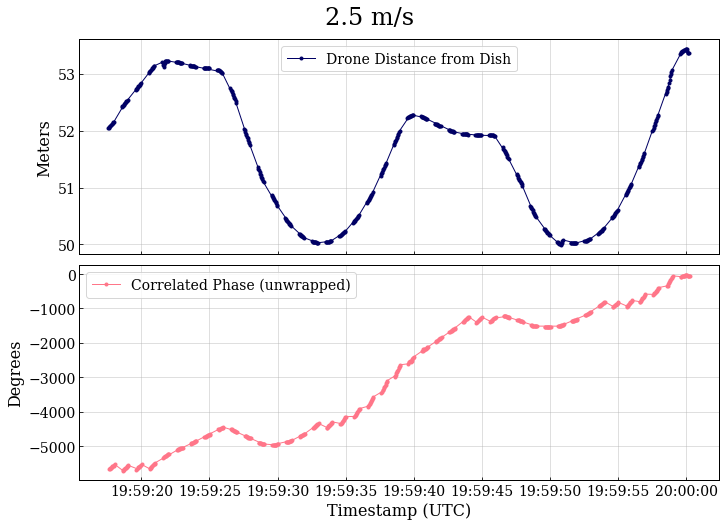

In [22]:
from datetime import datetime, timedelta

# ------------------------------------------------------------
# Correlator timestamps (TRUE / do not change)
# ------------------------------------------------------------
# Assumes you already have on_inds_sel and corr_data_s (like Cell 2).
# If times_dt_sel already exists, we reuse it.
try:
    times_dt_sel
except NameError:
    times_dt_all = [datetime.utcfromtimestamp(t[-1]) for t in corr_data_s.time]
    times_dt_sel = [times_dt_all[i] for i in on_inds_sel]

# ------------------------------------------------------------
# Apply time correction ONLY to drone, relative to correlator
# ------------------------------------------------------------
offset = -0.0632245  # seconds (same as your Cell 1 meaning)
times_dt_drone = [t + timedelta(seconds=offset) for t in times_dt_sel]  # shifted
times_dt_corr  = times_dt_sel  # unshifted (truth)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
cmap = plt.get_cmap('gnuplot2')
color_dist = cmap(0.10)
color_pow  = cmap(0.65)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ---- Top: Drone distance vs timestamp (SHIFTED) ----
ax1.plot(
    times_dt_drone,
    drone_dist_sel,
    linewidth=1,
    marker='.',
    color=color_dist,
    label="Drone Distance from Dish"
)

min_idx_dist = np.argmin(drone_dist_sel)
min_time_dist = times_dt_drone[min_idx_dist]

ax1.set_ylabel("Meters",fontsize=16)
#ax1.set_ylim(49.95,53)
ax1.grid(True)
ax1.legend(fontsize=14)

# ---- Bottom: Phase vs timestamp (UNSHIFTED / TRUE) ----
ax2.plot(
    times_dt_corr,
    phase_time_unwrap,
    linewidth=1,
    marker='.',
    color=color_pow,
    label="Correlated Phase (unwrapped)"
)

# Keep your same "2 to 26 seconds after start" window, but defined on correlator time
t0 = times_dt_corr[0]
#ax2.set_xlim(t0 + timedelta(seconds=2), t0 + timedelta(seconds=26))

ax2.set_xlabel("Timestamp (UTC)",fontsize=16)
ax2.set_ylabel("Degrees",fontsize=16)
ax2.grid(True)
ax2.legend(fontsize=14)

fig.suptitle("2.5 m/s", fontsize=24, y=0.9)
plt.tight_layout(rect=[0, 0, 1, 0.92])

ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='both', labelsize=14)


plt.show()


<ipython-input-23-21b703d6b32d>:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = plt.cm.get_cmap(base_cmap)


[7.51113874 7.39338581 7.27486274]
10.420431817654052
[3.87721213 3.7551143  3.63063699 3.5147367 ]
-6.208035402573651


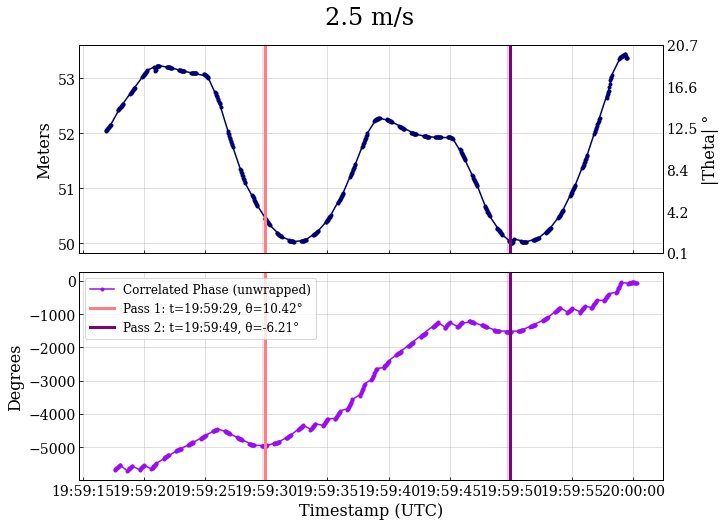

In [23]:
from matplotlib.colors import ListedColormap
from datetime import datetime, timedelta

# ------------------------------------------------------------
# Colormap setup (FROM YOUR NOTES)
# ------------------------------------------------------------
def cm_to_discrete(base_cmap, N):
    base = plt.cm.get_cmap(base_cmap)
    colors = base(np.linspace(0, 1, N))
    return ListedColormap(colors)

colorz = cm_to_discrete(plt.cm.gnuplot2, 10)

ca0x0      = colorz(0)   # auto
cc0x1      = 'purple'    # cross
ca1x1      = colorz(2)   # reference
cg0x0      = colorz(6)   # auto ghat
ca0x0_off  = colorz(7)   # off auto
cgB        = 'black'     # labels

# ------------------------------------------------------------
# Data prep (UNCHANGED)
# ------------------------------------------------------------
drone_angles = np.asarray(drone_angles)
drone_angles_sel = drone_angles[on_inds_sel]

try:
    times_dt_sel
except NameError:
    times_dt_all = [datetime.utcfromtimestamp(t[-1]) for t in corr_data_s.time]
    times_dt_sel = [times_dt_all[i] for i in on_inds_sel]

offset = -0.76
times_dt_drone = [t + timedelta(seconds=offset) for t in times_dt_sel]
times_dt_corr  = times_dt_sel

target_angles = [10.420431817654052, -6.208035402573651]

target_windows = [ (12.5+.25, 13.1),(32.85, 33.1)]

t0_drone = times_dt_drone[0]
times_sec = np.array([(t - t0_drone).total_seconds() for t in times_dt_drone])

vline_times = []

for target, (t_start, t_stop) in zip(target_angles, target_windows):
    mask = (times_sec >= t_start) & (times_sec <= t_stop)

    angles_window = drone_angles_sel[mask]
    times_window  = np.array(times_dt_drone)[mask]
    print(angles_window)
    print(target)

    idx_local = np.argmin(np.abs(angles_window - target))
    vline_times.append(times_window[idx_local])

# ------------------------------------------------------------
# COLOR ASSIGNMENTS (UPDATED)
# ------------------------------------------------------------
color_dist = colorz(1)        # drone distance
color_pow  = colorz(4)        # phase

# passes (use distinct but still from your scheme)
pass_colors = [cg0x0, 'purple']

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ---- Top: Drone distance ----
ax1.plot(
    times_dt_drone,
    drone_dist_sel,
    linewidth=1.5,
    marker='.',
    color=color_dist,
    label="Drone Distance from Dish"
)

ax1.set_ylabel("Meters", fontsize=16)
#ax1.set_ylim(49.95, 53)
ax1.grid(True)

# ---- Secondary axis ----
ax1b = ax1.twinx()

a_min, a_max = np.min(drone_angles_sel), np.max(drone_angles_sel)
a_min = max(0, a_min)

ax1b.set_ylim(a_min, a_max)

angle_ticks = np.linspace(a_min, a_max, 6)
angle_ticks = np.round(angle_ticks, 1)

ax1b.set_yticks(angle_ticks)
ax1b.set_ylabel("|Theta| °", fontsize=16)

ax1b.grid(False)
ax1b.tick_params(axis='y', length=0)

ax1.tick_params(axis='both', labelsize=14)
ax1b.tick_params(axis='both', labelsize=14)

# ---- Bottom: Phase ----
ax2.plot(
    times_dt_corr,
    phase_time_unwrap,
    linewidth=1.5,
    marker='.',
    color=color_pow,
    label="Correlated Phase (unwrapped)"
)

t0 = times_dt_corr[0]
#ax2.set_xlim(t0 + timedelta(seconds=11), t0 + timedelta(seconds=13))

ax2.set_xlabel("Timestamp (UTC)", fontsize=16)
ax2.set_ylabel("Degrees", fontsize=16)
ax2.grid(True)
#ax2.set_ylim(80, 110)

fig.suptitle("2.5 m/s", fontsize=24, y=0.9)
plt.tight_layout(rect=[0, 0, 1, 0.92])

ax2.tick_params(axis='both', labelsize=14)

# ------------------------------------------------------------
# Highlight regions + lines
# ------------------------------------------------------------
legend_entries = []

for i, ((t_start, t_stop), t_center, ang, color) in enumerate(
    zip(target_windows, vline_times, target_angles, pass_colors)
):
    t_start_dt = t0_drone + timedelta(seconds=t_start)
    t_stop_dt  = t0_drone + timedelta(seconds=t_stop)

    # shaded
    ax1.axvspan(t_start_dt, t_stop_dt, color=color, alpha=0.15)
    ax2.axvspan(t_start_dt, t_stop_dt, color=color, alpha=0.15)

    # vertical lines (thicker for paper clarity)
    ax1.axvline(t_center, color=color, linewidth=3)
    ax2.axvline(t_center, color=color, linewidth=3)

    label = f"Pass {i+1}: t={t_center.strftime('%H:%M:%S')}, θ={ang:.2f}°"
    legend_entries.append((color, label))

# legend
handles, labels = ax2.get_legend_handles_labels()

for color, label in legend_entries:
    handles.append(plt.Line2D([0], [0], color=color, linewidth=3))
    labels.append(label)

ax2.legend(handles, labels, fontsize=12)

plt.show()



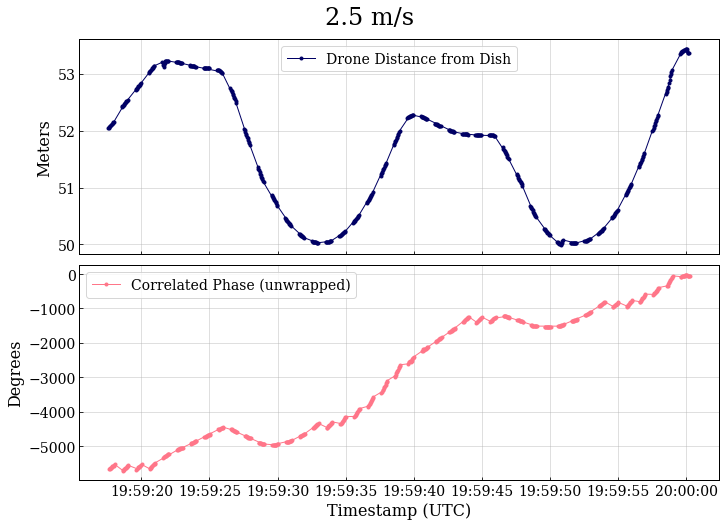

In [24]:
from datetime import datetime, timedelta

# ------------------------------------------------------------
# Correlator timestamps (TRUE / do not change)
# ------------------------------------------------------------
# Assumes you already have on_inds_sel and corr_data_s (like Cell 2).
# If times_dt_sel already exists, we reuse it.
try:
    times_dt_sel
except NameError:
    times_dt_all = [datetime.utcfromtimestamp(t[-1]) for t in corr_data_s.time]
    times_dt_sel = [times_dt_all[i] for i in on_inds_sel]

# ------------------------------------------------------------
# Apply time correction ONLY to drone, relative to correlator
# ------------------------------------------------------------
offset = -0.0632245  # seconds (same as your Cell 1 meaning)
times_dt_drone = [t + timedelta(seconds=offset) for t in times_dt_sel]  # shifted
times_dt_corr  = times_dt_sel  # unshifted (truth)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
cmap = plt.get_cmap('gnuplot2')
color_dist = cmap(0.10)
color_pow  = cmap(0.65)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ---- Top: Drone distance vs timestamp (SHIFTED) ----
ax1.plot(
    times_dt_drone,
    drone_dist_sel,
    linewidth=1,
    marker='.',
    color=color_dist,
    label="Drone Distance from Dish"
)

min_idx_dist = np.argmin(drone_dist_sel)
min_time_dist = times_dt_drone[min_idx_dist]

ax1.set_ylabel("Meters",fontsize=16)
#ax1.set_ylim(49.95,53)
ax1.grid(True)
ax1.legend(fontsize=14)

# ---- Bottom: Phase vs timestamp (UNSHIFTED / TRUE) ----
ax2.plot(
    times_dt_corr,
    phase_time_unwrap,
    linewidth=1,
    marker='.',
    color=color_pow,
    label="Correlated Phase (unwrapped)"
)

# Keep your same "2 to 26 seconds after start" window, but defined on correlator time
t0 = times_dt_corr[0]
#ax2.set_xlim(t0 + timedelta(seconds=2), t0 + timedelta(seconds=26))

ax2.set_xlabel("Timestamp (UTC)",fontsize=16)
ax2.set_ylabel("Degrees",fontsize=16)
ax2.grid(True)
ax2.legend(fontsize=14)

fig.suptitle("2.5 m/s", fontsize=24, y=0.9)
plt.tight_layout(rect=[0, 0, 1, 0.92])

ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='both', labelsize=14)


plt.show()


In [25]:
import pandas as pd
import os

run_name = input("Enter a name for this run (e.g. slow_pass_01): ")

# -------------------------------
# Distance data (RAW TIME)
# -------------------------------
df_dist = pd.DataFrame({
    "run": run_name,
    "signal": "distance",
    "time_s": times_sec,          # <-- UN-SHIFTED time
    "value": drone_dist_sel
})

# -------------------------------
# Power data (RAW TIME)
# -------------------------------
df_pow = pd.DataFrame({
    "run": run_name,
    "signal": "power",
    "time_s": times_sec,          # already raw
    "value": pow_mag_sel
})

df_all = pd.concat([df_dist, df_pow], ignore_index=True)

outfile = "distance_power_timeseries_master_og_dishloc.csv"

if os.path.exists(outfile):
    df_all.to_csv(outfile, mode="a", header=False, index=False)
else:
    df_all.to_csv(outfile, index=False)

print(f"Saved {len(df_all)} rows to {outfile}")
print(f"Run name: {run_name}")

Enter a name for this run (e.g. slow_pass_01): 2.5ms
Saved 952 rows to distance_power_timeseries_master_og_dishloc.csv
Run name: 2.5ms


In [26]:
# import pandas as pd
# import os

# run_name = input("Enter a name for this run (e.g. slow_pass_01): ")

# # -------------------------------
# # Distance data (RAW TIME)
# # -------------------------------
# df_dist = pd.DataFrame({
#     "run": run_name,
#     "signal": "distance",
#     "time_s": times_sec,          # <-- UN-SHIFTED time
#     "value": drone_dist_sel
# })

# # -------------------------------
# # Power data (RAW TIME)
# # -------------------------------
# df_pow = pd.DataFrame({
#     "run": run_name,
#     "signal": "power",
#     "time_s": times_sec,          # already raw
#     "value": pow_mag_sel
# })

# df_all = pd.concat([df_dist, df_pow], ignore_index=True)

# outfile = "distance_power_timeseries_master.csv"

# if os.path.exists(outfile):
#     df_all.to_csv(outfile, mode="a", header=False, index=False)
# else:
#     df_all.to_csv(outfile, index=False)

# print(f"Saved {len(df_all)} rows to {outfile}")
# print(f"Run name: {run_name}")

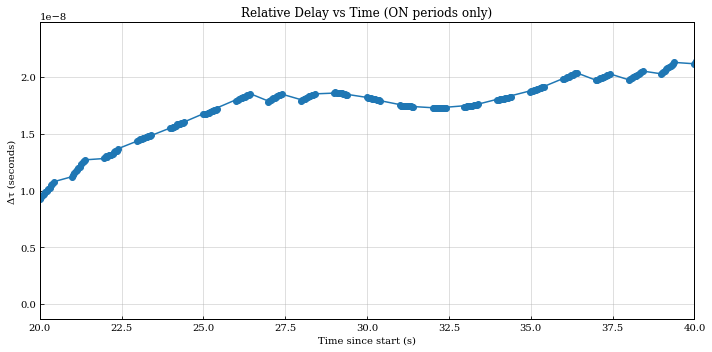

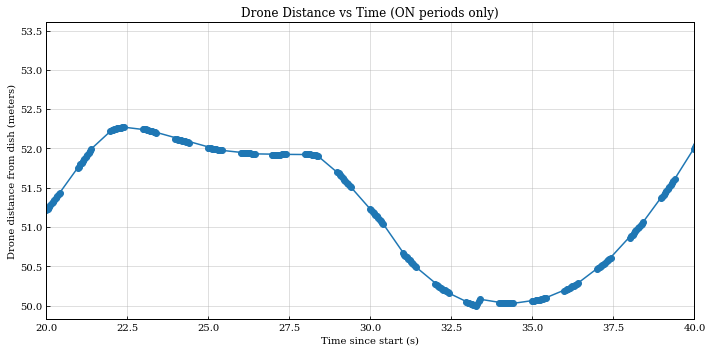

In [27]:
# -------------------------------
# Plot delay vs time
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(times_sec, tau_t_rel, marker='o')
plt.xlabel("Time since start (s)")
plt.ylabel("Δτ (seconds)")
plt.title("Relative Delay vs Time (ON periods only)")
plt.xlim(20,40)
plt.grid(True)
plt.tight_layout()

# -------------------------------
# Plot absolute drone distance vs time
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(times_sec, drone_dist_sel, marker='o')
plt.xlim(20,40)
plt.xlabel("Time since start (s)")
plt.ylabel("Drone distance from dish (meters)")
plt.title("Drone Distance vs Time (ON periods only)")
plt.grid(True)
plt.tight_layout()

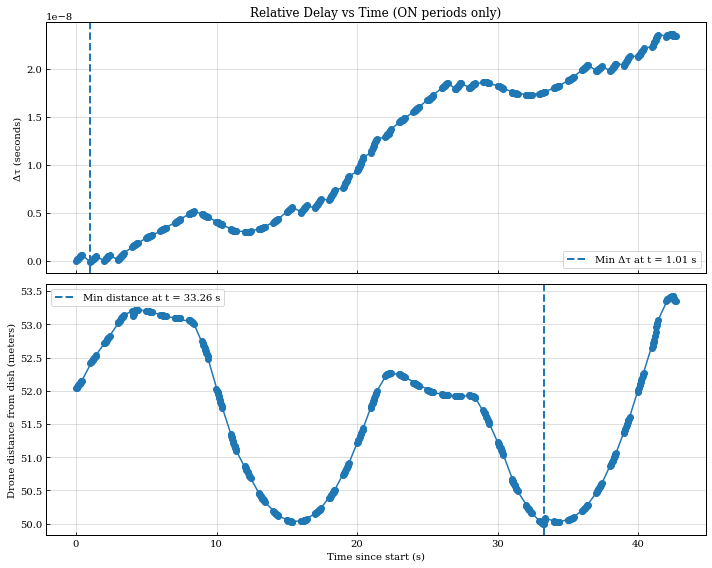

In [28]:
# Find indices and times of minima
min_tau_idx = np.argmin(tau_t_rel)
min_dist_idx = np.argmin(drone_dist_sel)

min_tau_time = times_sec[min_tau_idx]
min_dist_time = times_sec[min_dist_idx]

# -------------------------------
# Combined plot with shared x-axis
# -------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True
)

# ---- Top: Delay vs time ----
ax1.plot(times_sec, tau_t_rel, marker='o')
ax1.axvline(min_tau_time, linestyle='--', linewidth=2,
            label=f"Min Δτ at t = {min_tau_time:.2f} s")
ax1.set_ylabel("Δτ (seconds)")
ax1.set_title("Relative Delay vs Time (ON periods only)")
ax1.grid(True)
ax1.legend()

# ---- Bottom: Drone distance vs time ----
ax2.plot(times_sec, drone_dist_sel, marker='o')
ax2.axvline(min_dist_time, linestyle='--', linewidth=2,
            label=f"Min distance at t = {min_dist_time:.2f} s")
ax2.set_xlabel("Time since start (s)")
ax2.set_ylabel("Drone distance from dish (meters)")
ax2.grid(True)
ax2.legend()

# Shared x limits
#ax2.set_xlim(20, 40)

plt.tight_layout()
plt.show()


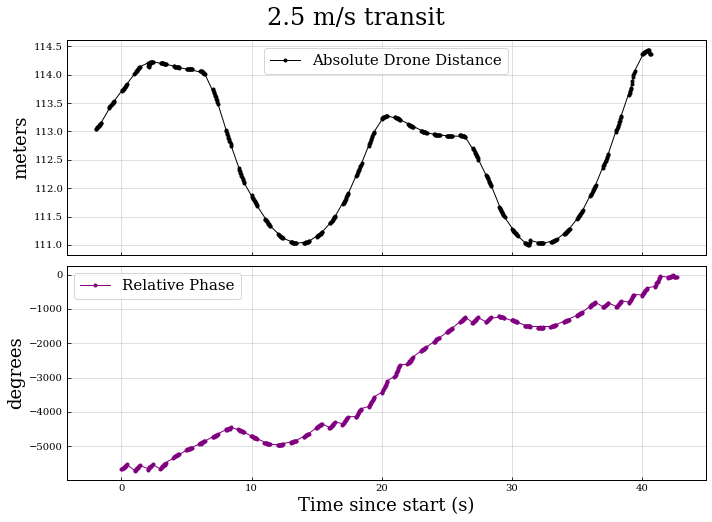

In [29]:
# -------------------------------
# Combined plot with shared x-axis
# -------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True
)

# ---- Top: Drone distance vs time ----
ax1.plot(
    times_sec - 1.9735,
    drone_dist_sel+61,
    linewidth=1,
    marker='.',
    color='black',
    label="Absolute Drone Distance"
)
#ax1.set_ylim(49.9, 51.175)
ax1.set_ylabel("meters",fontsize=18)
ax1.grid(True)
ax1.legend(fontsize=15)

# ---- Bottom: Delay vs time ----
ax2.plot(
    times_sec,
    phase_time_unwrap,
    linewidth=1,
    marker='.',
    color='purple',
    label="Relative Phase"
)
#ax2.set_ylim(2.5e-9, 5e-9)
ax2.set_xlabel("Time since start (s)",fontsize=18)
ax2.set_ylabel("degrees",fontsize=18)
ax2.grid(True)
ax2.legend(fontsize=15)

# Shared x limits
#ax2.set_xlim(24, 31.5)

# ---- Figure title (lowered slightly) ----
fig.suptitle(
    "2.5 m/s transit",
    fontsize=24,
    y=0.9
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


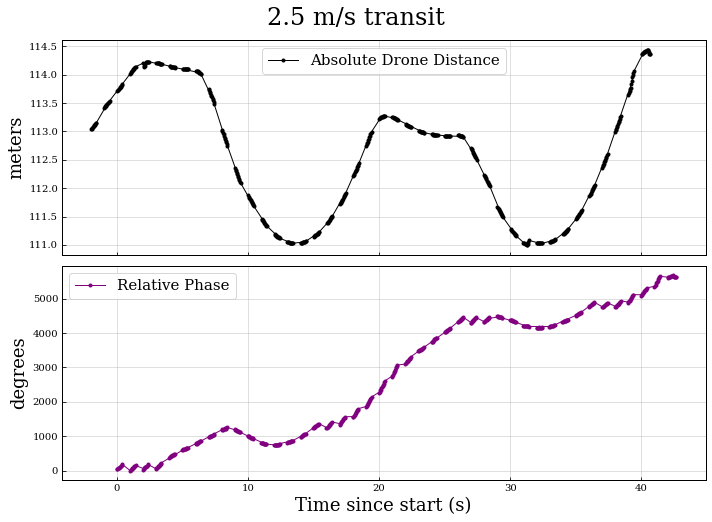

In [30]:
# -------------------------------
# Combined plot with shared x-axis
# -------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True
)

# ---- Top: Drone distance vs time ----
ax1.plot(
    times_sec - 1.9735,
    drone_dist_sel + 61,
    linewidth=1,
    marker='.',
    color='black',
    label="Absolute Drone Distance"
)
#ax1.set_ylim(49.9, 51.175)
ax1.set_ylabel("meters", fontsize=18)
ax1.grid(True)
ax1.legend(fontsize=15)

# ---- Bottom: Phase vs time ----
# Shift phase so minimum value becomes zero
phase_scaled = phase_time_unwrap - np.min(phase_time_unwrap)

ax2.plot(
    times_sec,
    phase_scaled,
    linewidth=1,
    marker='.',
    color='purple',
    label="Relative Phase"
)

ax2.set_xlabel("Time since start (s)", fontsize=18)
ax2.set_ylabel("degrees", fontsize=18)
ax2.grid(True)
ax2.legend(fontsize=15)

# ---- Figure title ----
fig.suptitle(
    "2.5 m/s transit",
    fontsize=24,
    y=0.9
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
